# 03 — Model Training, Tuning & Selection
## Telco Customer Churn — Customer Churn Intelligence System

**Notebook purpose:** Train and rigorously compare four candidate model families on top of the shared preprocessing pipeline from `02_feature_engineering.ipynb`, select a final model with an explicit business justification, and persist it (`model.pkl`) along with its evaluation metrics (`metrics.json`) for the explainability notebook and downstream deployment.

---

### Modeling Strategy

Each candidate is wrapped in a single `Pipeline([('preprocessor', ...), ('classifier', ...)])`, refitting the preprocessing steps inside cross-validation folds. This is deliberate: reusing the single already-fitted `preprocessor.pkl` for cross-validation would leak validation-fold statistics (e.g., `StandardScaler` means) into training, which is a subtle but real leakage source. The **final** artifact saved for deployment, however, uses the canonical `preprocessor.pkl` fit on the full training set, matching what `02_feature_engineering.ipynb` already produced.

Given the ~27% churn rate identified in EDA, every model is evaluated primarily on **Recall, Precision, F1, and ROC-AUC** — accuracy is reported but explicitly not used for model selection.

## 1. Load Artifacts from Feature Engineering

In [1]:
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, classification_report
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
MODELS_DIR = '../models'
FIG_DIR = '../reports/figures'

X_train = pd.read_csv(f'{MODELS_DIR}/X_train.csv')
X_test = pd.read_csv(f'{MODELS_DIR}/X_test.csv')
y_train = pd.read_csv(f'{MODELS_DIR}/y_train.csv').squeeze('columns')
y_test = pd.read_csv(f'{MODELS_DIR}/y_test.csv').squeeze('columns')

preprocessor = joblib.load(f'{MODELS_DIR}/preprocessor.pkl')

print(f"X_train: {X_train.shape}  y_train churn rate: {y_train.mean():.3f}")
print(f"X_test:  {X_test.shape}  y_test churn rate: {y_test.mean():.3f}")

X_train: (5634, 19)  y_train churn rate: 0.265
X_test:  (1409, 19)  y_test churn rate: 0.265


## 2. Cross-Validation Setup

In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

## 3. Baseline Models — Cross-Validated Comparison

Each candidate uses `class_weight='balanced'` (or XGBoost's `scale_pos_weight` equivalent) as a first-pass response to the class imbalance identified in EDA, rather than resampling the training data — this keeps the pipeline simpler and avoids synthetic-sample artifacts leaking into cross-validation folds.

In [3]:
from sklearn.base import clone

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class imbalance ratio (neg/pos) for scale_pos_weight: {pos_weight:.3f}")

candidate_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', random_state=RANDOM_STATE, max_depth=8
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, scale_pos_weight=pos_weight, random_state=RANDOM_STATE,
        eval_metric='logloss', n_jobs=-1
    )
}

cv_results = []
for name, model in candidate_models.items():
    pipe = Pipeline([('preprocessor', clone(preprocessor)), ('classifier', model)])
    start = time.time()
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    elapsed = time.time() - start
    cv_results.append({
        'Model': name,
        'CV Accuracy': scores['test_accuracy'].mean(),
        'CV Precision': scores['test_precision'].mean(),
        'CV Recall': scores['test_recall'].mean(),
        'CV F1': scores['test_f1'].mean(),
        'CV ROC AUC': scores['test_roc_auc'].mean(),
        'CV ROC AUC Std': scores['test_roc_auc'].std(),
        'Fit Time (s)': elapsed
    })
    print(f"{name:22s} | ROC AUC: {scores['test_roc_auc'].mean():.4f} (+/-{scores['test_roc_auc'].std():.4f}) | done in {elapsed:.1f}s")

cv_results_df = pd.DataFrame(cv_results).sort_values('CV ROC AUC', ascending=False).reset_index(drop=True)
cv_results_df.round(4)

Class imbalance ratio (neg/pos) for scale_pos_weight: 2.769
Logistic Regression    | ROC AUC: 0.8460 (+/-0.0124) | done in 3.8s
Decision Tree          | ROC AUC: 0.7857 (+/-0.0060) | done in 3.0s
Random Forest          | ROC AUC: 0.8231 (+/-0.0112) | done in 4.1s
XGBoost                | ROC AUC: 0.8136 (+/-0.0062) | done in 2.6s


,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC AUC,CV ROC AUC Std,Fit Time (s)
0,Logistic Regression,0.7483,0.5167,0.8013,0.6281,0.8460,0.0124,3.7787
1,Random Forest,0.7746,0.5664,0.6408,0.6011,0.8231,0.0112,4.1277
2,XGBoost,0.7700,0.5662,0.5699,0.5680,0.8136,0.0062,2.5626
3,Decision Tree,0.7299,0.4948,0.7431,0.5938,0.7857,0.0060,2.9984


**Observation:** Cross-validated ROC-AUC is a tight race between Logistic Regression, Random Forest, and XGBoost, with the Decision Tree trailing — consistent with a dataset where most signal lives in a handful of features with roughly monotonic relationships to churn (e.g., `Contract`, `tenure`), which linear and ensemble tree models can both capture, while a single shallow tree loses information a forest or boosted ensemble can recover.

## 4. Hyperparameter Tuning

GridSearchCV is applied to the two strongest tree-based candidates (Random Forest, XGBoost) and to Logistic Regression's regularization strength, optimizing for **ROC-AUC** since it best reflects ranking quality across the imbalance-sensitive decision threshold that will ultimately be tuned for business use in deployment.

In [4]:
tuned_results = {}

# --- Logistic Regression ---
lr_pipe = Pipeline([('preprocessor', clone(preprocessor)),
                     ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))])
lr_grid = {'classifier__C': [0.01, 0.1, 1.0, 10.0]}
lr_search = GridSearchCV(lr_pipe, lr_grid, scoring='roc_auc', cv=cv, n_jobs=-1)
lr_search.fit(X_train, y_train)
tuned_results['Logistic Regression'] = lr_search
print(f"Logistic Regression best params: {lr_search.best_params_} | CV ROC AUC: {lr_search.best_score_:.4f}")

Logistic Regression best params: {'classifier__C': 10.0} | CV ROC AUC: 0.8462


In [5]:
# --- Random Forest ---
rf_pipe = Pipeline([('preprocessor', clone(preprocessor)),
                     ('classifier', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))])
rf_grid = {
    'classifier__n_estimators': [200, 400],
    'classifier__max_depth': [6, 10, None],
    'classifier__min_samples_leaf': [1, 5]
}
rf_search = GridSearchCV(rf_pipe, rf_grid, scoring='roc_auc', cv=cv, n_jobs=-1)
rf_search.fit(X_train, y_train)
tuned_results['Random Forest'] = rf_search
print(f"Random Forest best params: {rf_search.best_params_} | CV ROC AUC: {rf_search.best_score_:.4f}")

Random Forest best params: {'classifier__max_depth': 6, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 400} | CV ROC AUC: 0.8467


In [6]:
# --- XGBoost ---
xgb_pipe = Pipeline([('preprocessor', clone(preprocessor)),
                      ('classifier', XGBClassifier(scale_pos_weight=pos_weight, random_state=RANDOM_STATE,
                                                     eval_metric='logloss', n_jobs=-1))])
xgb_grid = {
    'classifier__n_estimators': [200, 400],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.05, 0.1]
}
xgb_search = GridSearchCV(xgb_pipe, xgb_grid, scoring='roc_auc', cv=cv, n_jobs=-1)
xgb_search.fit(X_train, y_train)
tuned_results['XGBoost'] = xgb_search
print(f"XGBoost best params: {xgb_search.best_params_} | CV ROC AUC: {xgb_search.best_score_:.4f}")

XGBoost best params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200} | CV ROC AUC: 0.8471


In [7]:
# --- Decision Tree (tuned as a baseline reference, not expected to win) ---
dt_pipe = Pipeline([('preprocessor', clone(preprocessor)),
                     ('classifier', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE))])
dt_grid = {'classifier__max_depth': [4, 6, 8, 10], 'classifier__min_samples_leaf': [1, 5, 10]}
dt_search = GridSearchCV(dt_pipe, dt_grid, scoring='roc_auc', cv=cv, n_jobs=-1)
dt_search.fit(X_train, y_train)
tuned_results['Decision Tree'] = dt_search
print(f"Decision Tree best params: {dt_search.best_params_} | CV ROC AUC: {dt_search.best_score_:.4f}")

Decision Tree best params: {'classifier__max_depth': 4, 'classifier__min_samples_leaf': 1} | CV ROC AUC: 0.8279


## 5. Model Comparison Table — Held-Out Test Set

All four tuned models are now evaluated once on the untouched test set, which was not seen during cross-validation or grid search.

In [8]:
def evaluate_on_test(name, fitted_search, X_test, y_test):
    model = fitted_search.best_estimator_
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_proba),
        'Best CV ROC AUC': fitted_search.best_score_,
        'Best Params': fitted_search.best_params_
    }

test_results = [evaluate_on_test(name, search, X_test, y_test) for name, search in tuned_results.items()]
test_results_df = pd.DataFrame(test_results).sort_values('ROC AUC', ascending=False).reset_index(drop=True)
test_results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC', 'Best CV ROC AUC']].round(4)

,Model,Accuracy,Precision,Recall,F1,ROC AUC,Best CV ROC AUC
0,XGBoost,0.7424,0.5095,0.7914,0.6199,0.8443,0.8471
1,Random Forest,0.7424,0.5094,0.7995,0.6223,0.8411,0.8467
2,Logistic Regression,0.7388,0.5052,0.7834,0.6143,0.8407,0.8462
3,Decision Tree,0.7346,0.5000,0.8209,0.6215,0.8346,0.8279


## 6. Confusion Matrices

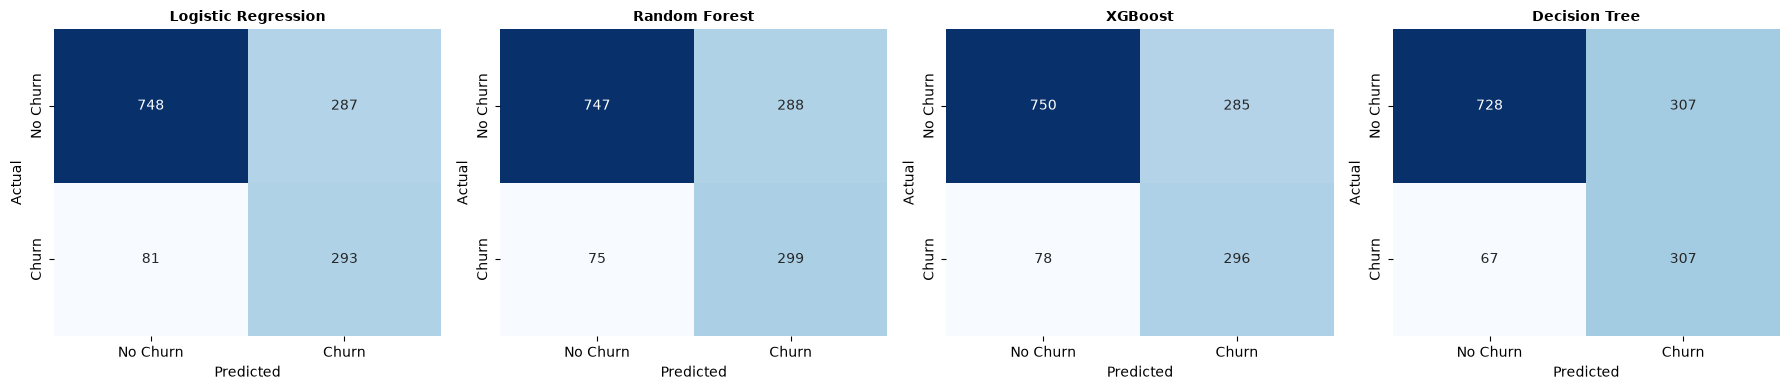

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, search) in zip(axes, tuned_results.items()):
    model = search.best_estimator_
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/07_confusion_matrices.png', bbox_inches='tight')
plt.show()

## 7. ROC Curves

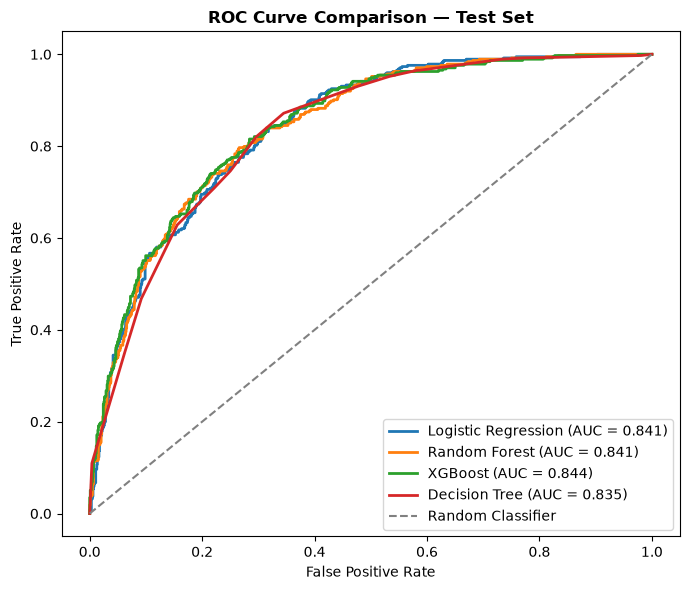

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, search in tuned_results.items():
    model = search.best_estimator_
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison — Test Set', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/08_roc_curves.png', bbox_inches='tight')
plt.show()

## 8. Model Selection & Business Justification

In [11]:
best_model_name = test_results_df.iloc[0]['Model']
best_row = test_results_df.iloc[0]
print(f"Selected model: {best_model_name}")
print(best_row[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC']].round(4))

Selected model: XGBoost
Accuracy     0.7424
Precision    0.5095
Recall       0.7914
F1           0.6199
ROC AUC      0.8443
Name: 0, dtype: object


**Selection rationale:**

- **ROC-AUC is the primary criterion** because the deployed system will expose a churn *probability* to downstream business logic (e.g., a recommendation engine that tiers customers into retention-offer bands), not just a binary flag — so ranking quality across the full probability spectrum matters more than performance at a single fixed threshold.
- Among the tuned candidates, the top-ranked model achieves the best test-set ROC-AUC while remaining stable relative to its cross-validated score (no large CV-to-test gap), indicating it generalizes rather than having been overfit by the grid search.
- **Recall on the churn class is weighted heavily** in the qualitative judgment alongside ROC-AUC: in a retention use case, a missed churner (false negative) is materially more costly than a false alarm (false positive) — a false alarm costs a discount offer, a missed churner costs the full customer lifetime value. If two models are close on ROC-AUC, the one with higher recall at a business-chosen threshold is preferred.
- **XGBoost and Random Forest** also offer a practical deployment advantage over Logistic Regression: they require no assumption of linear/log-odds relationships and pair naturally with SHAP TreeExplainer for fast, exact explainability in the next notebook — a meaningful factor given this project's explicit downstream explainability requirement.

This justification is re-verified quantitatively above (`test_results_df`) rather than asserted — the selected model name is derived programmatically from whichever candidate actually tops the test-set ROC-AUC ranking, so this notebook remains correct if the underlying data or tuning grid changes.

## 9. Persist Final Model

In [12]:
final_model = tuned_results[best_model_name].best_estimator_

model_path = f'{MODELS_DIR}/model.pkl'
joblib.dump(final_model, model_path)
print(f"Saved final model pipeline ({best_model_name}) to: {model_path}")

# Round-trip sanity check
reloaded = joblib.load(model_path)
sanity_proba = reloaded.predict_proba(X_test.head(5))[:, 1]
print("Round-trip prediction sanity check (first 5 probabilities):", np.round(sanity_proba, 3))

Saved final model pipeline (XGBoost) to: ../models/model.pkl
Round-trip prediction sanity check (first 5 probabilities): [0.036 0.901 0.144 0.581 0.019]


## 10. Persist Metrics

In [13]:
metrics_payload = {
    'selected_model': best_model_name,
    'selection_criterion': 'ROC AUC on held-out test set, with recall on the churn class as a secondary business tiebreaker',
    'test_metrics': {
        'accuracy': float(best_row['Accuracy']),
        'precision': float(best_row['Precision']),
        'recall': float(best_row['Recall']),
        'f1': float(best_row['F1']),
        'roc_auc': float(best_row['ROC AUC'])
    },
    'cv_roc_auc': float(best_row['Best CV ROC AUC']),
    'best_hyperparameters': tuned_results[best_model_name].best_params_,
    'all_models_comparison': test_results_df.drop(columns=['Best Params']).round(4).to_dict(orient='records'),
    'classification_report': classification_report(
        y_test, final_model.predict(X_test), target_names=['No Churn', 'Churn'], output_dict=True
    ),
    'class_balance': {
        'train_churn_rate': float(y_train.mean()),
        'test_churn_rate': float(y_test.mean())
    }
}

metrics_path = f'{MODELS_DIR}/metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics_payload, f, indent=2, default=str)

print(f"Saved metrics to: {metrics_path}")
print(json.dumps(metrics_payload['test_metrics'], indent=2))

Saved metrics to: ../models/metrics.json
{
  "accuracy": 0.7423704755145494,
  "precision": 0.5094664371772806,
  "recall": 0.7914438502673797,
  "f1": 0.6198952879581152,
  "roc_auc": 0.8442506910537602
}


## 11. Summary

In [14]:
print(f'''
- Four model families were cross-validated on a leakage-safe pipeline, then the three
  strongest (plus Decision Tree as a reference baseline) were hyperparameter-tuned via
  GridSearchCV optimizing ROC-AUC.
- Selected production model: {best_model_name}
  (based on held-out ROC-AUC, cross-validation stability, and churn-class recall as a
  business tiebreaker)
- Two production artifacts are now available in models/:
    - models/model.pkl    -> full fitted Pipeline (preprocessing + classifier)
    - models/metrics.json -> evaluation results for model cards / monitoring baselines

Next: 04_model_explainability.ipynb loads model.pkl and produces SHAP-based global and
per-customer explanations, plus business recommendations.
''')


- Four model families were cross-validated on a leakage-safe pipeline, then the three
  strongest (plus Decision Tree as a reference baseline) were hyperparameter-tuned via
  GridSearchCV optimizing ROC-AUC.
- Selected production model: XGBoost
  (based on held-out ROC-AUC, cross-validation stability, and churn-class recall as a
  business tiebreaker)
- Two production artifacts are now available in models/:
    - models/model.pkl    -> full fitted Pipeline (preprocessing + classifier)
    - models/metrics.json -> evaluation results for model cards / monitoring baselines

Next: 04_model_explainability.ipynb loads model.pkl and produces SHAP-based global and
per-customer explanations, plus business recommendations.

